# Mini Project — Simple Stock Trading Strategy

## FinTech and Quantitative Trading

### Project Objective

In this mini project, we will build a simple rule-based stock trading strategy using Python.

The strategy uses a **20-day Moving Average (MA20)** to generate simple trading signals.

### Learning Goals

By completing this project, we will learn how to:
1. Obtain historical stock-price data.
2. Explore financial data using Pandas.
3. Calculate daily returns.
4. Calculate a Moving Average.
5. Generate simple BUY/SELL signals.
6. Calculate strategy returns.
7. Compare the strategy with Buy-and-Hold.
8. Visualize price, signals, and performance.

> **Important:** This is an educational project, not investment advice.

## 1. The Basic Idea

The project follows:

**Stock Data → Daily Return → Moving Average → Trading Signal → Strategy Return → Performance Comparison**

### Trading Rule

- If **Close Price > MA20** → hold the stock (`Signal = 1`)
- If **Close Price ≤ MA20** → stay out of the market (`Signal = 0`)

### Key Terms

- **Close Price**: closing price of the stock for a trading day.
- **Return**: percentage change in value.
- **Moving Average**: average price over a selected number of previous periods.
- **Trading Signal**: rule-based indication of whether the strategy is invested.
- **Buy-and-Hold**: buy the stock and keep the position.
- **Volatility**: a measure of return fluctuation.

**Indonesian:** Moving Average = rata-rata bergerak; Trading Signal = sinyal perdagangan; Return = tingkat pengembalian.

## 2. Import Libraries

We use:
- `pandas` for data manipulation.
- `numpy` for numerical operations.
- `matplotlib` for visualization.
- `yfinance` for historical market data.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [21]:
!pip install yfinance

## 3. Download Stock Data

We use **Samsung Electronics**, ticker `005930.KS`.

The `.KS` suffix identifies the Korea Exchange market in Yahoo Finance.

`yf.download()` returns historical market data such as Open, High, Low, Close, and Volume.

In [22]:
ticker = "005930.KS"

data = yf.download(
    ticker,
    start="2025-01-01",
    end="2026-01-01",
    auto_adjust=False
)

# Convert MultiIndex columns to single-level columns
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2025-01-02,52107.089844,53400.0,53600.0,52300.0,52700.0,16630538
2025-01-03,53082.882812,54400.0,55100.0,52800.0,52800.0,19318046
2025-01-06,54546.558594,55900.0,56200.0,54300.0,54400.0,19034284
2025-01-07,54058.667969,55400.0,57300.0,55400.0,56800.0,17030235
2025-01-08,55912.667969,57300.0,57500.0,54700.0,54800.0,26593553


## 4. Basic Data Exploration

Before calculating indicators, inspect the dataset.

This is an important data-analysis habit: understand the data before using it.

In [23]:
print("Number of rows:", len(data))
print("Number of columns:", len(data.columns))

data.info()

Number of rows: 241
Number of columns: 6
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 241 entries, 2025-01-02 to 2025-12-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  241 non-null    float64
 1   Close      241 non-null    float64
 2   High       241 non-null    float64
 3   Low        241 non-null    float64
 4   Open       241 non-null    float64
 5   Volume     241 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 13.2 KB


In [24]:
data.describe()

Price,Adj Close,Close,High,Low,Open,Volume
count,241.000000,241.000000,241.000000,241.000000,241.000000,2.410000e+02
mean,70411.275901,71415.975104,72261.410788,70526.141079,71346.473029,1.927372e+07
std,19488.096757,19343.977421,19616.448362,18941.606025,19300.628174,7.587199e+06
min,49765.199219,51000.000000,51400.000000,50800.000000,51100.000000,5.848342e+06
25%,54772.484375,55900.000000,56500.000000,55500.000000,56100.000000,1.384171e+07
50%,60243.992188,61400.000000,61700.000000,60500.000000,61300.000000,1.797322e+07
75%,84341.593750,85400.000000,85900.000000,83700.000000,84900.000000,2.299451e+07
max,119520.531250,119900.000000,121200.000000,118700.000000,119400.000000,5.482456e+07


### Interpretation

`describe()` gives statistics such as mean, standard deviation, minimum, maximum, and percentiles.

The exact values depend on the historical data returned when the notebook is run.

## 5. Calculate Daily Return

Daily return measures the percentage change from one closing price to the next:

\[
R_t = \frac{P_t-P_{t-1}}{P_{t-1}}
\]

Pandas' `.pct_change()` performs this calculation.

The first row becomes `NaN` because there is no previous trading day.

In [25]:
data["Daily_Return"] = data["Close"].pct_change()

data[["Close", "Daily_Return"]].head(10)

Price,Close,Daily_Return
Date,,
2025-01-02,53400.0,NaN
2025-01-03,54400.0,0.018727
2025-01-06,55900.0,0.027574
2025-01-07,55400.0,-0.008945
2025-01-08,57300.0,0.034296
2025-01-09,56100.0,-0.020942
2025-01-10,55300.0,-0.014260
2025-01-13,54100.0,-0.021700
2025-01-14,53900.0,-0.003697


In [26]:
average_return = data["Daily_Return"].mean()
volatility = data["Daily_Return"].std()

print(f"Average Daily Return: {average_return:.4%}")
print(f"Daily Volatility: {volatility:.4%}")

Average Daily Return: 0.3607%
Daily Volatility: 2.1610%


### Interpretation

- **Average Daily Return** = average daily percentage change.
- **Daily Volatility** = standard deviation of daily returns.

Higher volatility means returns fluctuate more.

## 6. Calculate the 20-Day Moving Average

A 20-day Moving Average is the average closing price over the latest 20 trading observations:

\[
MA_{20,t}=\frac{P_t+P_{t-1}+...+P_{t-19}}{20}
\]

The window moves forward one trading day at a time.

We use it as a simple trend indicator for this educational project.

In [27]:
data["MA20"] = data["Close"].rolling(window=20).mean()

data[["Close", "MA20"]].tail(10)

Price,Close,MA20
Date,,
2025-12-16,102800.0,103330.0
2025-12-17,107900.0,103900.0
2025-12-18,107600.0,104250.0
2025-12-19,106300.0,104825.0
2025-12-22,110500.0,105515.0
2025-12-23,111500.0,106125.0
2025-12-24,111100.0,106540.0
2025-12-26,117000.0,107215.0
2025-12-29,119500.0,108165.0


The first 19 MA20 values are `NaN` because 20 observations are needed to calculate the first complete 20-day average.

## 7. Generate Trading Signals

### Rule

```text
Close > MA20  → Signal = 1
Close ≤ MA20  → Signal = 0
```

- `1` means the strategy is invested.
- `0` means the strategy is outside the market.

`np.where()` works like a simple IF/ELSE condition.

In [28]:
data["Signal"] = np.where(
    data["Close"] > data["MA20"],
    1,
    0
)

data[["Close", "MA20", "Signal"]].tail(20)

Price,Close,MA20,Signal
Date,,,
2025-12-02,103400.0,100110.0,1
2025-12-03,104500.0,100305.0,1
2025-12-04,105100.0,100600.0,1
2025-12-05,108400.0,101125.0,1
2025-12-08,109500.0,101570.0,1
2025-12-09,108400.0,101815.0,1
2025-12-10,108000.0,102060.0,1
2025-12-11,107300.0,102285.0,1
2025-12-12,108900.0,102870.0,1


## 8. Calculate Strategy Return

We use:

\[
Strategy\ Return_t = Signal_{t-1}\times Return_t
\]

The previous signal is used with today's return.

### Why `.shift(1)`?

Using the previous signal helps avoid a simple form of **look-ahead bias**.

**Look-ahead bias** means using information that would not have been available when the trading decision was made.

In [29]:
data["Strategy_Return"] = (
    data["Signal"].shift(1) * data["Daily_Return"]
)

data[
    ["Close", "MA20", "Signal", "Daily_Return", "Strategy_Return"]
].tail(10)

Price,Close,MA20,Signal,Daily_Return,Strategy_Return
Date,,,,,
2025-12-16,102800.0,103330.0,0,-0.019084,-0.019084
2025-12-17,107900.0,103900.0,1,0.049611,0.000000
2025-12-18,107600.0,104250.0,1,-0.002780,-0.002780
2025-12-19,106300.0,104825.0,1,-0.012082,-0.012082
2025-12-22,110500.0,105515.0,1,0.039511,0.039511
2025-12-23,111500.0,106125.0,1,0.009050,0.009050
2025-12-24,111100.0,106540.0,1,-0.003587,-0.003587
2025-12-26,117000.0,107215.0,1,0.053105,0.053105
2025-12-29,119500.0,108165.0,1,0.021368,0.021368


## 9. Calculate Cumulative Performance

A daily return describes one day. Cumulative performance shows how an initial value would grow over the whole period.

We start with an initial value of `1.0` and compound the returns using `.cumprod()`.

In [30]:
data["Cumulative_Market"] = (
    1 + data["Daily_Return"].fillna(0)
).cumprod()

data["Cumulative_Strategy"] = (
    1 + data["Strategy_Return"].fillna(0)
).cumprod()

data[
    [
        "Close",
        "Signal",
        "Daily_Return",
        "Strategy_Return",
        "Cumulative_Market",
        "Cumulative_Strategy"
    ]
].tail()

Price,Close,Signal,Daily_Return,Strategy_Return,Cumulative_Market,Cumulative_Strategy
Date,,,,,,
2025-12-23,111500.0,1,0.009050,0.009050,2.088015,1.602125
2025-12-24,111100.0,1,-0.003587,-0.003587,2.080524,1.596378
2025-12-26,117000.0,1,0.053105,0.053105,2.191011,1.681154
2025-12-29,119500.0,1,0.021368,0.021368,2.237828,1.717076
2025-12-30,119900.0,1,0.003347,0.003347,2.245318,1.722823


## 10. Compare Buy-and-Hold with the Strategy

**Buy-and-Hold** stays invested throughout the period.

The **MA20 Strategy** is invested only when `Close > MA20`.

A benchmark is useful because a strategy should not be evaluated in isolation.

In [31]:
market_return = data["Cumulative_Market"].iloc[-1] - 1
strategy_return = data["Cumulative_Strategy"].iloc[-1] - 1

print(f"Buy-and-Hold Return: {market_return:.2%}")
print(f"MA20 Strategy Return: {strategy_return:.2%}")

Buy-and-Hold Return: 124.53%
MA20 Strategy Return: 72.28%


### How to read the result

If the cumulative value is `1.20`, an initial value of 1.00 became 1.20, corresponding to a 20% cumulative return.

The result applies only to this historical sample. This simple backtest does not include transaction costs, taxes, slippage, liquidity constraints, or other real-world factors.

## 11. Visualize Price and Moving Average

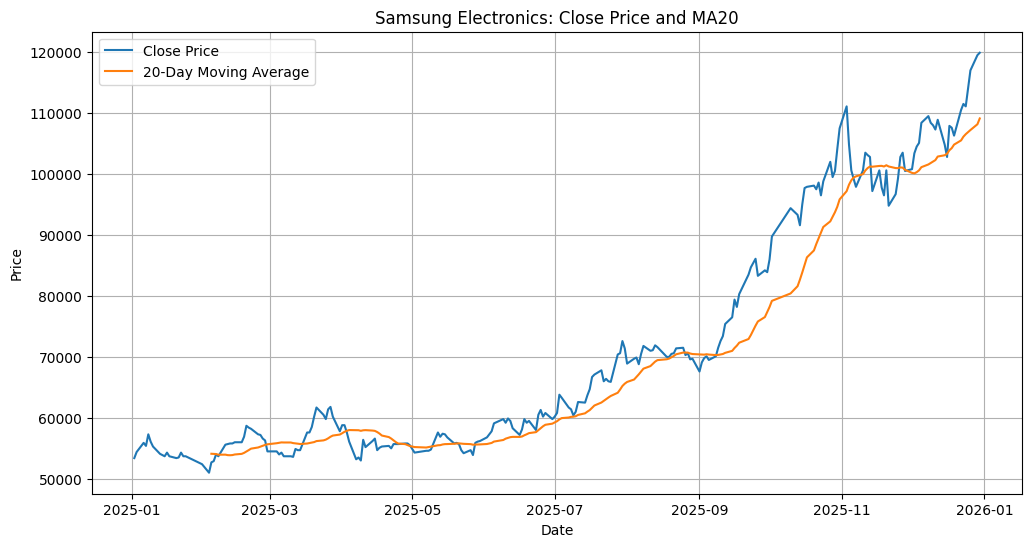

In [32]:
plt.figure(figsize=(12, 6))

plt.plot(data.index, data["Close"], label="Close Price")
plt.plot(data.index, data["MA20"], label="20-Day Moving Average")

plt.title("Samsung Electronics: Close Price and MA20")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()

plt.show()

The Moving Average should appear smoother than the closing-price series because it averages multiple observations.

## 12. Visualize Strategy Performance

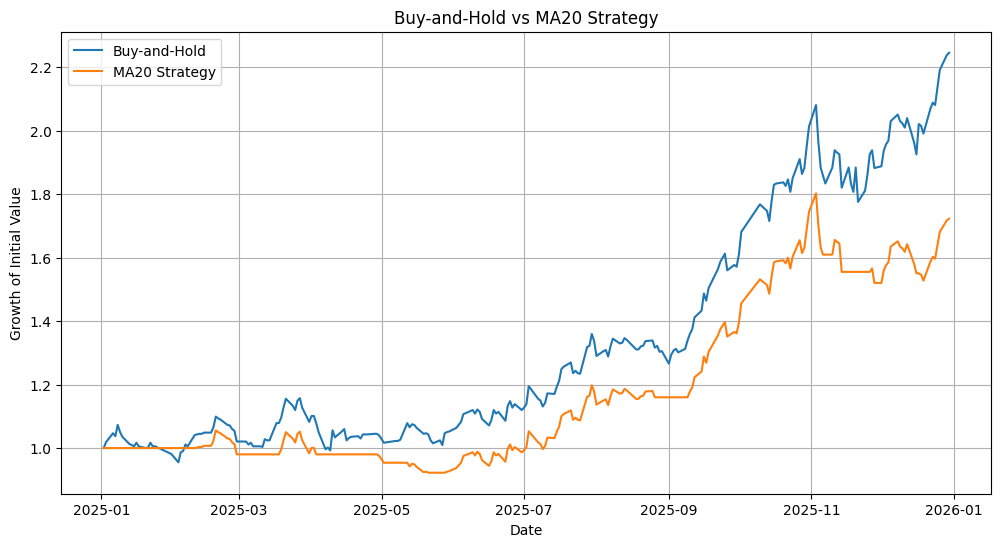

In [33]:
plt.figure(figsize=(12, 6))

plt.plot(
    data.index,
    data["Cumulative_Market"],
    label="Buy-and-Hold"
)

plt.plot(
    data.index,
    data["Cumulative_Strategy"],
    label="MA20 Strategy"
)

plt.title("Buy-and-Hold vs MA20 Strategy")
plt.xlabel("Date")
plt.ylabel("Growth of Initial Value")
plt.legend()
plt.grid()

plt.show()

## 13. Identify BUY and SELL Signal Changes

A signal change means:

- `0 → 1` = entering the market.
- `1 → 0` = leaving the market.

We can count these changes to understand how often the strategy changes position.

In [34]:
buy_signals = data[
    (data["Signal"] == 1) &
    (data["Signal"].shift(1) == 0)
]

sell_signals = data[
    (data["Signal"] == 0) &
    (data["Signal"].shift(1) == 1)
]

print("Number of BUY signal changes:", len(buy_signals))
print("Number of SELL signal changes:", len(sell_signals))

Number of BUY signal changes: 10
Number of SELL signal changes: 9


## 14. Plot BUY and SELL Signals

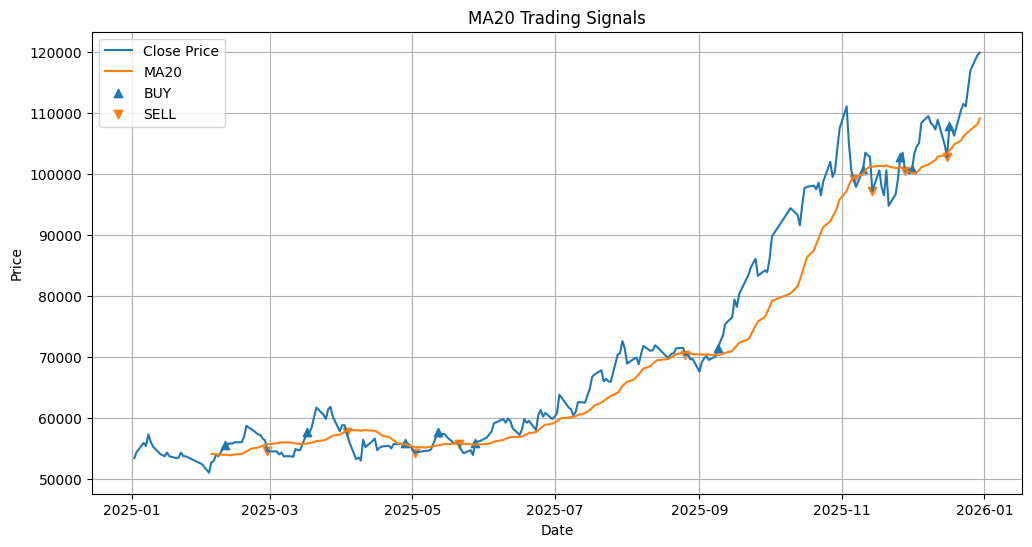

In [35]:
plt.figure(figsize=(12, 6))

plt.plot(data.index, data["Close"], label="Close Price")
plt.plot(data.index, data["MA20"], label="MA20")

plt.scatter(
    buy_signals.index,
    buy_signals["Close"],
    marker="^",
    label="BUY"
)

plt.scatter(
    sell_signals.index,
    sell_signals["Close"],
    marker="v",
    label="SELL"
)

plt.title("MA20 Trading Signals")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()

plt.show()

## 15. Final Data Check

This table connects the main concepts:

**Price → Indicator → Signal → Return → Strategy Performance**

In [36]:
data[
    [
        "Close",
        "MA20",
        "Signal",
        "Daily_Return",
        "Strategy_Return",
        "Cumulative_Market",
        "Cumulative_Strategy"
    ]
].tail(15)

Price,Close,MA20,Signal,Daily_Return,Strategy_Return,Cumulative_Market,Cumulative_Strategy
Date,,,,,,,
2025-12-09,108400.0,101815.0,1,-0.010046,-0.010046,2.029963,1.634855
2025-12-10,108000.0,102060.0,1,-0.003690,-0.003690,2.022472,1.628822
2025-12-11,107300.0,102285.0,1,-0.006481,-0.006481,2.009363,1.618265
2025-12-12,108900.0,102870.0,1,0.014911,0.014911,2.039326,1.642396
2025-12-15,104800.0,103080.0,1,-0.037649,-0.037649,1.962547,1.580561
2025-12-16,102800.0,103330.0,0,-0.019084,-0.019084,1.925094,1.550397
2025-12-17,107900.0,103900.0,1,0.049611,0.000000,2.020599,1.550397
2025-12-18,107600.0,104250.0,1,-0.002780,-0.002780,2.014981,1.546087
2025-12-19,106300.0,104825.0,1,-0.012082,-0.012082,1.990637,1.527407


## 16. Final Conclusion

This project implemented a simple Moving Average trading strategy using historical Samsung Electronics stock data.

The strategy generated an invested position when the closing price was above the 20-day moving average and stayed outside the market otherwise.

The strategy was compared with a Buy-and-Hold benchmark.

### Key Learning Points

1. Financial data can be represented and analyzed using a Pandas DataFrame.
2. Daily returns measure percentage price changes.
3. Moving averages can be calculated with a rolling window.
4. Trading rules can be converted into numerical signals.
5. `.shift(1)` helps prevent a simple form of look-ahead bias.
6. Cumulative returns allow performance to be evaluated over time.
7. A trading strategy should be compared with a benchmark.

### Result

Run the notebook to obtain the exact numerical results:

- Buy-and-Hold Return: **see output above**
- MA20 Strategy Return: **see output above**

This project is intentionally simplified. A real quantitative trading system would require additional considerations such as transaction costs, slippage, liquidity, risk management, position sizing, and out-of-sample testing.